# Step 1: Imports and Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("sales_data.csv")

# Step 2: Pandas Operations

## Data Exploration

In [3]:
df.head()
df.shape 
df.tail()
df.info()
df.describe() 
df.dtypes
df.columns.tolist()
df.nunique()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            1000 non-null   str    
 1    order_value_EUR   1000 non-null   str    
 2    cost              1000 non-null   float64
 3   date               1000 non-null   str    
 4   category           1000 non-null   str    
 5   customer_name      1000 non-null   str    
 6   sales_manager      1000 non-null   str    
 7   sales_rep          1000 non-null   str    
 8   device_type        1000 non-null   str    
 9   order_id           1000 non-null   str    
dtypes: float64(1), str(9)
memory usage: 167.8 KB


country                15
 order_value_EUR     1000
 cost                1000
date                  536
category               10
customer_name          75
sales_manager          15
sales_rep              35
device_type             3
order_id             1000
dtype: int64

## Data Cleaning

In [5]:
df.columns = df.columns.str.strip()
df['order_value_EUR'] = df['order_value_EUR'].str.replace(',', '').astype(float)
df.isnull().sum()
df.duplicated().sum()
df = df.drop_duplicates()
df.shape
df=df.dropna()
df.shape

(1000, 10)

## Filtering and Selection

In [6]:
df["country"].head()
df[["country", "category", "order_value_EUR"]].head()
df.loc[df["order_value_EUR"] > 100000].head() # Filter orders above €100k
df[(df["country"] == "Sweden") & (df["category"] == "Books")].head()
df["country"].value_counts()

country
Portugal       239
France         232
Sweden         182
UK             101
Finland         44
Ireland         43
Bulgaria        30
Netherlands     28
Spain           26
Germany         24
Luxembourg      22
Denmark         11
Italy           10
Belgium          6
Austria          2
Name: count, dtype: int64

## Data Transformation & Merging

In [7]:
country_targets = pd.DataFrame({
    "country": df['country'].unique()[:4], # Taking the first 4 unique countries
    "sales_target": [500000, 400000, 450000, 350000]
})
df = df.merge(country_targets, on="country", how="left")
df[["country", "order_value_EUR", "sales_target"]].head()
df["date"] = pd.to_datetime(df["date"])
df["order_month"] = df["date"].dt.month_name()
df["profit"] = df["order_value_EUR"] - df["cost"]
df["profit_margin_pct"] = (df["profit"] / df["order_value_EUR"] * 100).round(2)

df[["date", "order_month", "order_value_EUR", "profit", "profit_margin_pct"]].head()

,date,order_month,order_value_EUR,profit,profit_margin_pct
0,2020-02-12,February,17524.02,3401.41,19.41
1,2019-09-26,September,116563.40,23755.62,20.38
2,2019-07-11,July,296465.56,38985.22,13.15
3,2020-04-02,April,74532.02,14779.70,19.83
4,2019-12-22,December,178763.42,32141.66,17.98


# Step 3: Visualization (Matplotlib & Seaborn)

Monthly Sales Trend (Line Chart)

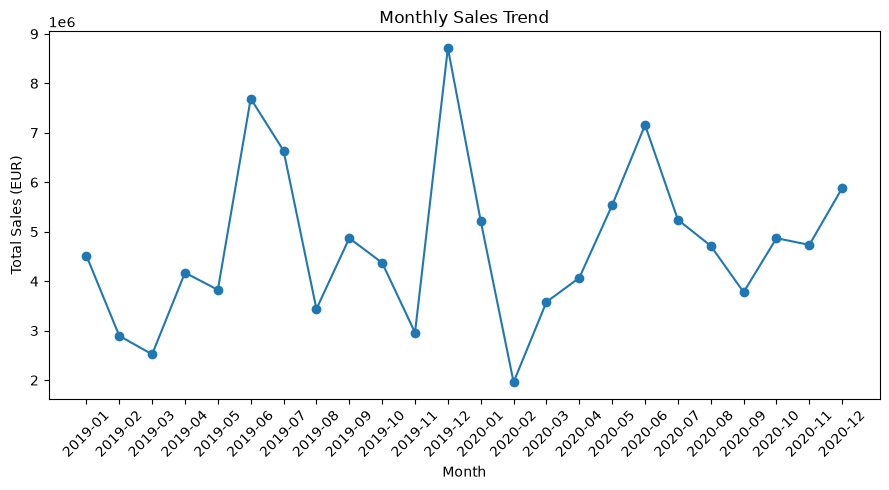

In [8]:
monthly_sales = df.groupby(df["date"].dt.to_period("M"))["order_value_EUR"].sum()
plt.figure(figsize=(9,5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o')
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Total Sales (EUR)")
plt.title("Monthly Sales Trend")
plt.tight_layout()
plt.show()

Total Sales by Country (Bar Chart)

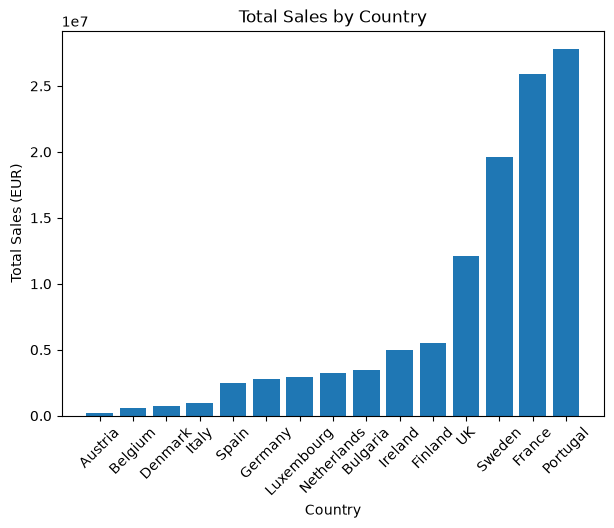

In [9]:
country_sales = df.groupby("country")["order_value_EUR"].sum().sort_values(ascending=True)
plt.figure(figsize=(7,5))
plt.bar(country_sales.index, country_sales.values)
plt.xlabel("Country")
plt.ylabel("Total Sales (EUR)")
plt.title("Total Sales by Country")
plt.xticks(rotation=45)
plt.show()

Distribution of Profit Margin (Histogram)

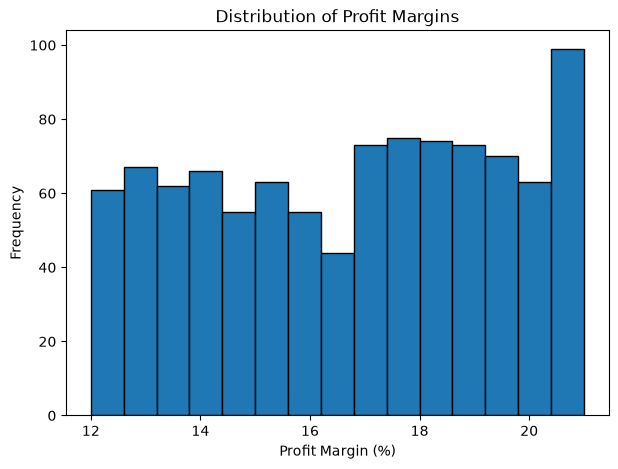

In [10]:
plt.figure(figsize=(7,5))
plt.hist(df["profit_margin_pct"], bins=15, edgecolor="black")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Profit Margins")
plt.show()

Sales vs Profit (Scatter Plot)

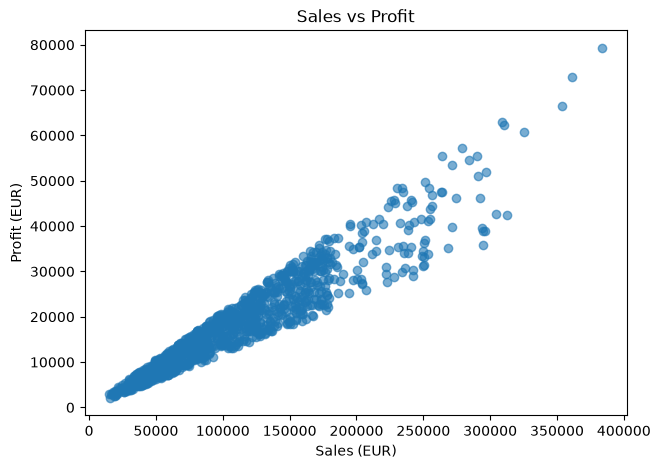

In [11]:
plt.figure(figsize=(7,5))
plt.scatter(df["order_value_EUR"], df["profit"], alpha=0.6)
plt.xlabel("Sales (EUR)")
plt.ylabel("Profit (EUR)")
plt.title("Sales vs Profit")
plt.show()

Sales Distribution with KDE (Seaborn Histplot)

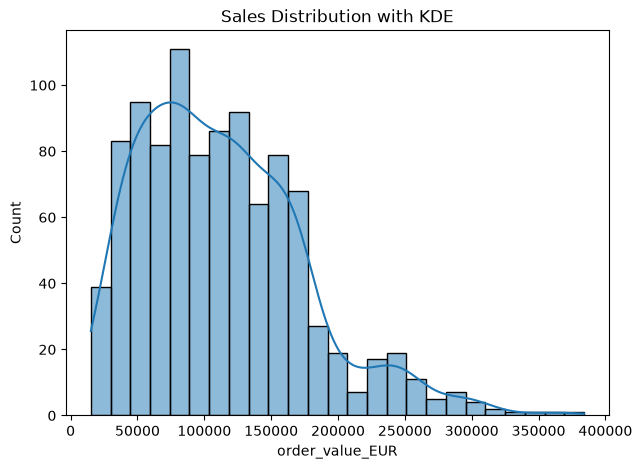

In [12]:
plt.figure(figsize=(7,5))
sns.histplot(df["order_value_EUR"], bins=25, kde=True)
plt.title("Sales Distribution with KDE")
plt.show()

Profit Distribution by Country (Seaborn Boxplot)

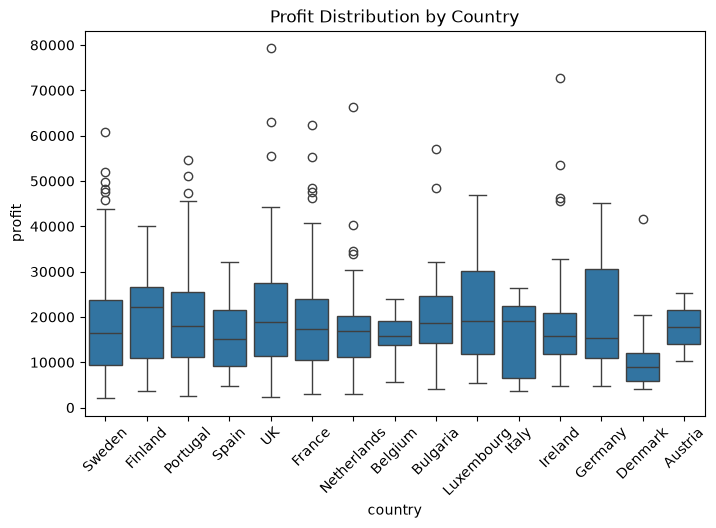

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x="country", y="profit", data=df)
plt.title("Profit Distribution by Country")
plt.xticks(rotation=45)
plt.show()

Sales Distribution by Category (Seaborn Violin Plot)

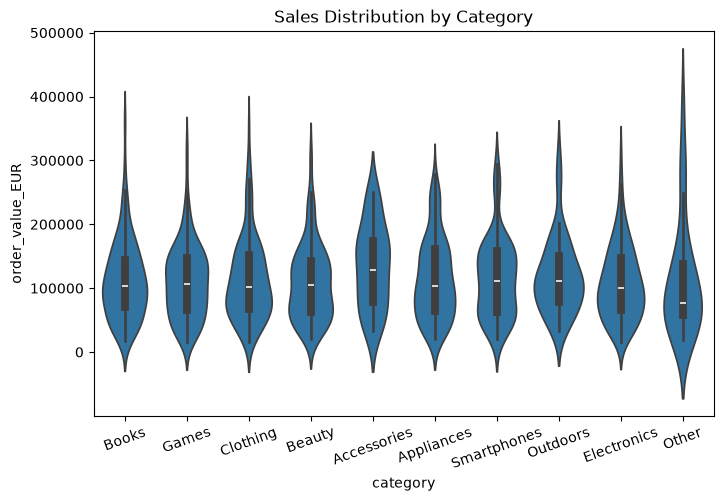

In [14]:
plt.figure(figsize=(8,5))
sns.violinplot(x="category", y="order_value_EUR", data=df)
plt.xticks(rotation=20)
plt.title("Sales Distribution by Category")
plt.show()

In [15]:
print(df.columns)

Index(['country', 'order_value_EUR', 'cost', 'date', 'category',
       'customer_name', 'sales_manager', 'sales_rep', 'device_type',
       'order_id', 'sales_target', 'order_month', 'profit',
       'profit_margin_pct'],
      dtype='str')
